# Projet: Analyse des données et pre-processing

Eduardo Cobos Fernandez, Sipan Bareyan Jeremy Rakotorinira, Amine Berrahma 

Analyse et réduction des bias en Machine Learning

# 0 - Introduction

Ce projet s'inscrit dans le cadre de l'analyse et la réduction des biais en Machine Learning appliqué au domaine médical. Les modèles de prédiction utilisés en imagerie médicale peuvent hériter des biais présents dans les données d'entraînement, conduisant à des performances inéquitables selon certains groupes de patients.

IL s’appuie sur le dataset Chest X-ray NIH14 (https://www.kaggle.com/datasets/nih-chest-xrays/data), qui contient des radiographies thoraciques ainsi que des métadonnées associées aux patients, telles que l’âge, le genre et les pathologies diagnostiquées. L'objectif est de classifier chaque radiographie comme saine ou malade, tout en garantissant l'équité du modèle vis-à-vis des attributs sensibles.

Ce notebook est structuré en trois parties :

- **Analyse des données** : analyse univariée, bivariée et multivariée des métadonnées afin d'identifier les déséquilibres et biais présents dans le dataset

- **Pre-processing** : application de la méthode de Reweighting sur les attributs sensibles genre et âge, suivi de l'entraînement d'un modèle ResNet18 et de l'évaluation de son impact sur les performances et les métriques d'équité.

- **Post-processing** : correction des prédictions du modèle entraîné via deux méthodes (Reject-Option Classification et Calibrated Equalized Odds), ainsi que l'étude des combinaisons pre + post-processing.

# Chargement des données

Les métadonnées du dataset Chest X-ray NIH14 sont chargées à partir du fichier fourni pour le projet. Ce fichier contient les informations associées à un sous-ensemble de 6 000.

In [68]:
import pandas as pd
from aif360.sklearn.metrics import *

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy.stats import chi2_contingency

In [69]:
# On commence par charger les donnees depuis le csv
df = pd.read_csv("Cobos_Fernandez_Eduardo/metadata.csv")

# On peut regarder les premieres lignes du dataset 
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS
0,00000011_000.png,Effusion,0,11,75,M,PA,2638,2449,0.143,0.143,NaN,train,malade,1
1,00000011_001.png,No Finding,1,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
2,00000011_002.png,No Finding,2,11,75,M,PA,2714,2781,0.143,0.143,NaN,train,sain,1
3,00000011_003.png,No Finding,3,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
4,00000011_004.png,No Finding,4,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1


# 1 - Préparation des données :

Dans cette partie, une analyse est réalisée afin d’observer les dimensions du dataset, les types de variables ainsi que leur distribution. Une attention particulière est portée à la détection de valeurs aberrantes, notamment sur la variable âge, afin de garantir la cohérence des informations.

Enfin, certaines transformations sont effectuées pour faciliter l’analyse, notamment la création d’une variable binaire indiquant la présence ou l’absence de maladie, ainsi que la catégorisation de l’âge en groupes. Ces étapes permettent d’obtenir un dataset propre, structuré et adapté à l’analyse des biais

# Informations sur le Dataset

In [70]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5593 entries, 0 to 5592
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Image Index                  5593 non-null   object 
 1   Finding Labels               5593 non-null   object 
 2   Follow-up #                  5593 non-null   int64  
 3   Patient ID                   5593 non-null   int64  
 4   Patient Age                  5593 non-null   int64  
 5   Patient Gender               5593 non-null   object 
 6   View Position                5593 non-null   object 
 7   OriginalImage[Width          5593 non-null   int64  
 8   Height]                      5593 non-null   int64  
 9   OriginalImagePixelSpacing[x  5593 non-null   float64
 10  y]                           5593 non-null   float64
 11  Unnamed: 11                  0 non-null      float64
 12  train_valid                  5593 non-null   object 
 13  label             

On observe que le dataset contient 5593 observations de patients et 14 variables.
Ces variables sont composées d'informations démographiques (age, genre), d'informations techniques (position de vue, taille de l'image originelle, le spacing des pixels) ainsi que le nombre de visites effectués préalablement et si le patient il est malade ou sain (Finding Labels contient les maladies identifiés si il en a). Cette dernière information sera notre label car l'objectif est de prédire si le patient est malade ou pas. Additionnellement, on a comme information si l'image a été utilisée dans le train set ou le validation set et le poids avec lequel elle va être utilisée dans l'entrainement de notre modèle.

## Data Cleaning

Tout d'abord on a vu avec df.info() qu'il n'y a pas de valeurs nulles dans notre dataset sauf pour la colonne 'Unnamed: 11' qui est une erreur et tous les types des données sont bien placés. Pas besoin de traiter nos données pour ceci.


On remarque que les informations OriginalImage[Width, Height] et OriginalImagePixelSpacing[x y] données par les colonnes 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]' n'apportent aucune information intéressante. De même pour la colonne Unnamed: 11 qui c'est probablement glissée dans les métadonnées par erreur. On peut donc procéder à les supprimer. 

In [71]:
df = df.drop(columns=['OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11'])

In [72]:
df

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,train_valid,label,WEIGHTS
0,00000011_000.png,Effusion,0,11,75,M,PA,train,malade,1
1,00000011_001.png,No Finding,1,11,75,M,PA,train,sain,1
2,00000011_002.png,No Finding,2,11,75,M,PA,train,sain,1
3,00000011_003.png,No Finding,3,11,75,M,PA,train,sain,1
4,00000011_004.png,No Finding,4,11,75,M,PA,train,sain,1
...,...,...,...,...,...,...,...,...,...,...
5588,00030772_001.png,Consolidation,1,30772,26,F,AP,train,malade,1
5589,00030772_002.png,Consolidation,2,30772,26,F,AP,train,malade,1
5590,00030774_000.png,Consolidation,0,30774,44,F,PA,valid,malade,1
5591,00030784_000.png,No Finding,0,30784,25,F,PA,train,sain,1


À partir de ce que l'on a trouvé lors du mi-projet on peut faire le nettoyage de nos données rapidement. On regarde qu'il n'y ait pas d'index répétés, que les valeurs numériques soient cohérentes, que les valeurs de type object fassent partie des valeurs possibles.

In [73]:
if not (df['Image Index'].is_unique):
    print("Les index ne sont pas individuels")
if ((df["Follow-up #"] < 0).any()):
    print("Il y a des Follow-up négatifs")
if ((df["Patient Age"] < 0).any()):
    print("Il y a des âges négatifs")
if ((df["Patient Age"] > 110).any()):
    print("Il y a des âges plus grands que 110")
if (set(df["Patient Gender"]) != {'F', 'M'}):
    print("Le patient gender prend des valeurs différentes de \"M\" ou \"F\"")
if (set(df["View Position"]) != {'AP', 'PA'}):
    print("Le view position prend des valeurs différentes de \"AP\" ou \"PA\"")
if (set(df["train_valid"]) != {'train', 'valid'}):
    print("La colonne train_valid prend des valeurs différentes de \"train\" ou \"valid\"")
if (set(df["label"]) != {'malade', 'sain'}):
    print("La colonne label prend des valeurs différentes de \"malade\" ou \"sain\"")

Il y a des âges plus grands que 110


Le seul nettoyage à faire et donc sur les âges. On observe des âges supérieurs à 110 et biologiquement improbables. On les supprime directement car quelques valeurs dans un si grand dataset sont négligeables.

In [74]:
df = df[df["Patient Age"] <= 110]

## Transformation des colonnes

Pour l'analyse descriptive des données on va procéder à faire un multi one-hot encoding sur la colonne finding labels en créant une colonne par maladie.
De plus, afin de simplifier la lecture des données âge et pouvoir les utiliser dans le préprocessing on va la transformer en une donnée catégorielle en créant des tranches d'âges.

In [75]:
# on crée les tranches d'âge
df["Age_Group"] = pd.cut(
    df["Patient Age"],
    bins=[0, 20, 40, 60, 80, 120],
    labels=["0-20", "20-40", "40-60", "60-80", "80+"],
    right=False
)
# on ne supprime pas la colonne avec les âges exacts au cas ou on devrais en vaoir besoin après mais en principe il n'y a pas besoin 

/var/folders/2s/g233_y4543g3nv84_mqys8bc0000gp/T/ipykernel_2206/3346603339.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Age_Group"] = pd.cut(


In [76]:
# on crée les tranches de follow ups pour faciliter la visualisation
df["Follow-up_Group"] = pd.cut(
    df["Follow-up #"],
    bins=[0, 5, 10, 15, 25, 50, 500],
    labels=["0-5", "5-10", "10-15", "15-25", "25-50", "50+"],
    right=False
)
# on ne supprime pas la colonne avec les follow ups exacts au cas ou on devrais en vaoir besoin après mais en principe il n'y a pas besoin 

/var/folders/2s/g233_y4543g3nv84_mqys8bc0000gp/T/ipykernel_2206/1619576956.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Follow-up_Group"] = pd.cut(


In [77]:
# on fait le one_hot sur les pathologies
dummies = df["Finding Labels"].str.get_dummies(sep="|")

df_one_hot = pd.concat([df, dummies], axis=1)
df_one_hot = df_one_hot.drop(columns=["Finding Labels"])

In [78]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,train_valid,label,WEIGHTS,Age_Group,Follow-up_Group
0,00000011_000.png,Effusion,0,11,75,M,PA,train,malade,1,60-80,0-5
1,00000011_001.png,No Finding,1,11,75,M,PA,train,sain,1,60-80,0-5
2,00000011_002.png,No Finding,2,11,75,M,PA,train,sain,1,60-80,0-5
3,00000011_003.png,No Finding,3,11,75,M,PA,train,sain,1,60-80,0-5
4,00000011_004.png,No Finding,4,11,75,M,PA,train,sain,1,60-80,0-5


Maintenant on a deux tableaux, l'un avec les maladies codées en one-hot pour l'analyse et un sans le one-hot pour l'entrainement du modèle

## Analyse des données

Dans cette partie, on va réaliser une analyse univariée afin de comprendre la distribution individuelle des variables clés, telles que le genre, l’âge et le statut de maladie.

Avec une analyse bivariée on va ensuite examiner la relation entre les attributs sensibles (genre et groupes d’âge) et le label, afin de détecter d’éventuelles disparités.

Enfin, on va réaliser une analyse multivariée qui approfondi l’étude en combinant plusieurs variables, suivie du calcul de métriques d’équité telles que le Statistical Parity Difference et le Disparate Impact, ce qui permet de quantifier les biais potentiels présents dans les données.

### A) Analyse univarié

On va regarder les données importantes une par une et les analyser.

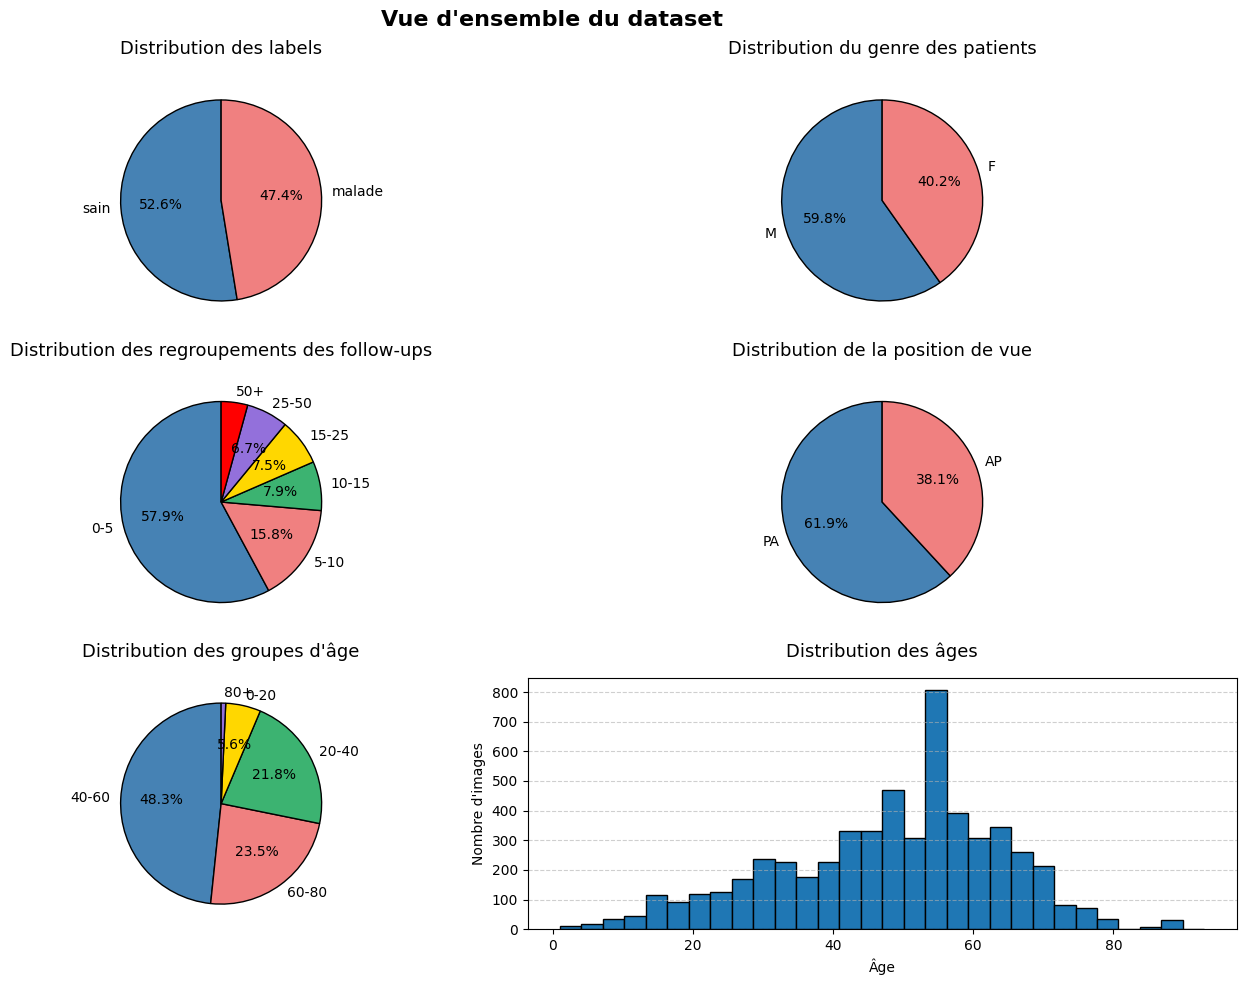

In [79]:
counts = [["label", "Patient Gender"], ["Follow-up_Group", "View Position"], ["Age_Group", "Patient Age"]]
titre = [["des labels", "du genre des patients"], ["des regroupements des follow-ups", "de la position de vue"], ["des groupes d'âge", "des âges"]]

fig, axes = plt.subplots(3, 2, figsize=(14,10))

for i in range(3):
    for j in range(2):
        if(i == 2 and j == 1):
            axes[i][j].hist(df[counts[i][j]], bins=30, edgecolor="black")
            axes[i][j].set_xlabel("Âge")
            axes[i][j].set_ylabel("Nombre d'images")
            axes[i][j].grid(axis="y", linestyle="--", alpha=0.6)
        else:
            axes[i][j].pie(
                df[counts[i][j]].value_counts(),
                labels = df[counts[i][j]].value_counts().index,
                autopct=lambda pct: f"{pct:.1f}%" if pct > 5 else "",
                startangle = 90,
                colors = ["steelblue", "lightcoral", "mediumseagreen", "gold", "mediumpurple", "red"] if ((i == 2 and j == 0) or (i == 1 and j == 0)) else ["steelblue", "lightcoral"],
                wedgeprops={"edgecolor": "black"},
            )

        axes[i][j].set_title(f"Distribution {titre[i][j]}", fontsize=13, pad=15)

fig.suptitle("Vue d'ensemble du dataset", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

L'analyse univariée révèle plusieurs caractéristiques importantes de notre dataset. On constate d'abord un léger déséquilibre de genre, avec 57% d'hommes contre 43% de femmes — un écart notable sans être extrême, mais qu'il faudra surveiller dans l'analyse des biais. Côté label, la répartition entre patients sains et malades montre [indiquer le ratio observé], ce qui [constitue/ne constitue pas] un déséquilibre significatif pour l'entraînement d'un modèle.
La distribution des âges se concentre principalement sur les tranches 40-60 et 60-80, avec une sous-représentation marquée des très jeunes (0-20) et des très âgés (80+). Cette asymétrie signifie que le modèle aura peu d'exemples pour ces groupes extrêmes, ce qui pourrait affecter ses performances sur ces populations. La position de vue est dominée par le PA, et les follow-ups se concentrent massivement dans la tranche 0-5, montrant que la majorité des patients n'ont que peu de visites enregistrées.

### B) Analyse bivariée

On va maintenant mettre en relation les données deux à deux et les analyser ainsi.

On commence avec les analyse bivariées vont avec le label

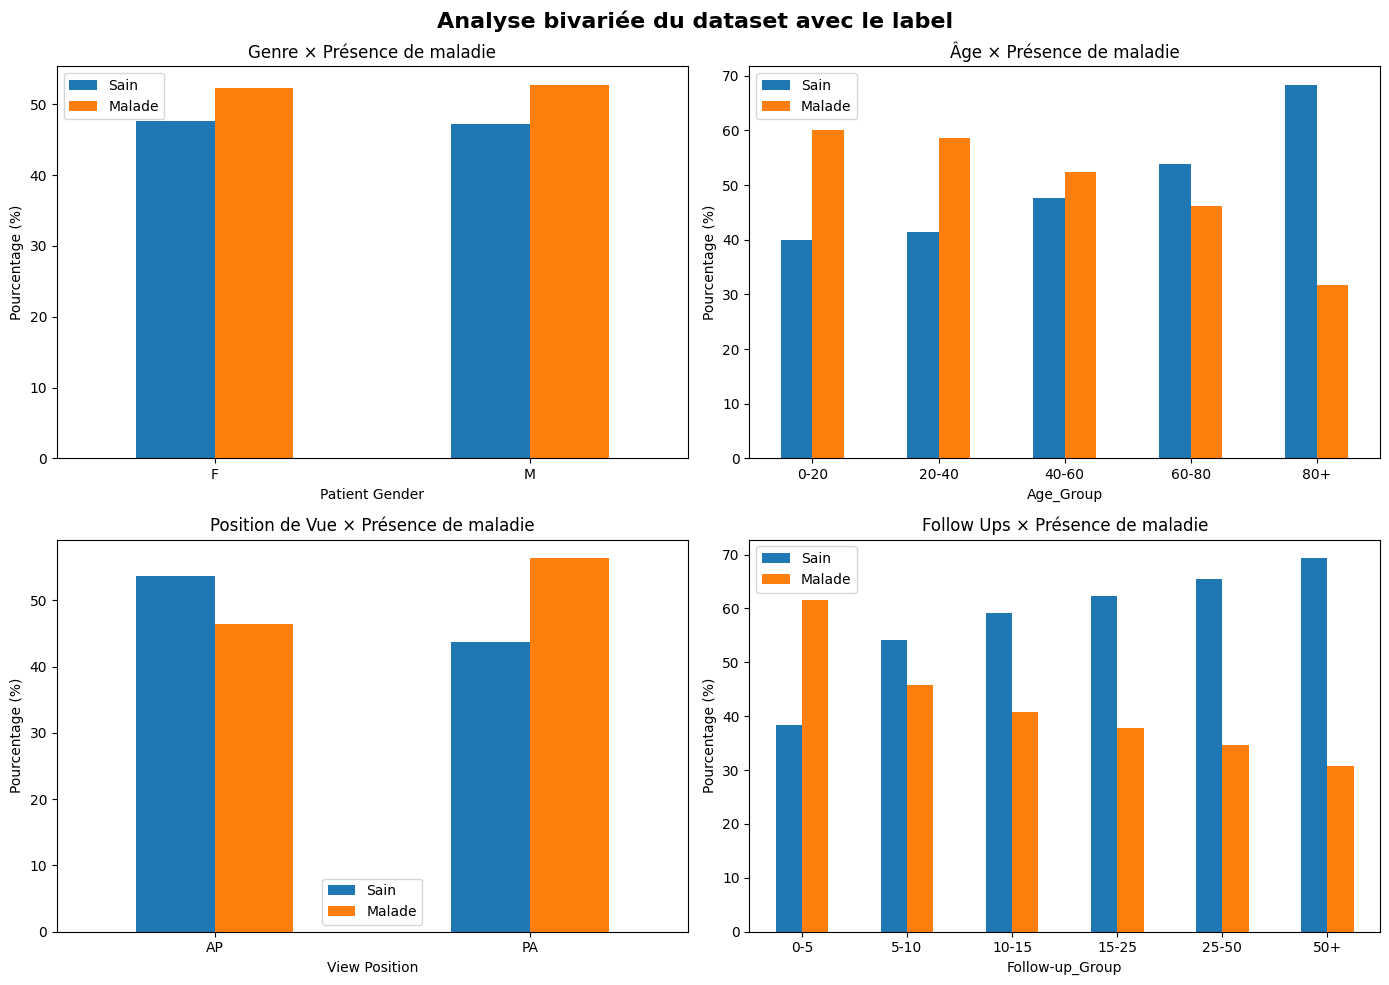

In [80]:
#Genre × Maladie
table_genre_maladie = pd.crosstab(
    df["Patient Gender"],
    df["label"],
    normalize="index"
) * 100

#Age_group × Maladie
table_age_maladie = pd.crosstab(
    df["Age_Group"],
    df["label"],
    normalize="index"
) * 100

#View Position × Maladie
table_View_maladie = pd.crosstab(
    df["View Position"],
    df["label"],
    normalize="index"
) * 100

#Follow ups × Maladie
table_Follow_maladie = pd.crosstab(
    df["Follow-up_Group"],
    df["label"],
    normalize="index"
) * 100

tables = [[table_genre_maladie, table_age_maladie], [table_View_maladie, table_Follow_maladie]]
titres = [["Genre × Présence de maladie", "Âge × Présence de maladie"], ["Position de Vue × Présence de maladie", "Follow Ups × Présence de maladie"]]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for i in range(2):
    for j in range(2):
        tables[i][j].plot(kind="bar", ax=axes[i][j])
        axes[i][j].set_ylabel("Pourcentage (%)")
        axes[i][j].tick_params(axis='x', rotation=0)
        axes[i][j].legend(["Sain", "Malade"])
        axes[i][j].set_title(titres[i][j])

fig.suptitle("Analyse bivariée du dataset avec le label", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [81]:
## analyse détaillée des résultats

#Genre × Maladie
diff_genre = table_genre_maladie.loc["M", "malade"] - table_genre_maladie.loc["F", "malade"]
rr_genre   = table_genre_maladie.loc["M", "malade"] / table_genre_maladie.loc["F", "malade"]
chi2, p_genre, _, _ = chi2_contingency(pd.crosstab(df["Patient Gender"], df["label"]))


print(f"  Taux malade Hommes : {table_genre_maladie.loc['M', 'malade']:.1f}%")
print(f"  Taux malade Femmes : {table_genre_maladie.loc['F', 'malade']:.1f}%")
print(f"  Différence H-F     : {diff_genre:+.2f}%")
print(f"  Risk Ratio (H/F)   : {rr_genre:.3f}")
print(f"  p-value            : {p_genre:.4f}")

#Age_group × Maladie , on prend comme référence le groupe 40-60 car c'est le plus représenté et le plus stable
diff_age = table_age_maladie["malade"] - table_age_maladie["malade"]["40-60"]
rr_age   = table_age_maladie["malade"] / table_age_maladie["malade"]["40-60"]
chi2, p_age, _, _ = chi2_contingency(pd.crosstab(df["Age_Group"], df["label"]))

print("\n")
print(f"  {'Groupe':<10} {'Taux malade':>12} {'Différence':>12} {'Risk Ratio':>12}")
for groupe in table_age_maladie.index:
    print(f"  {str(groupe):<10} {table_age_maladie.loc[groupe, 'malade']:>11.1f}%"
          f" {diff_age[groupe]:>+11.2f}%"
          f" {rr_age[groupe]:>12.3f}")
print(f"  p-value  : {p_age:.4f}")

#View Position × Maladie
diff_view = table_View_maladie.loc["AP", "malade"] - table_View_maladie.loc["PA", "malade"]
rr_view   = table_View_maladie.loc["AP", "malade"] / table_View_maladie.loc["PA", "malade"]
chi2, p_view, _, _ = chi2_contingency(pd.crosstab(df["View Position"], df["label"]))

print("\n")
print(f"  Taux malade AP   : {table_View_maladie.loc['AP', 'malade']:.1f}%")
print(f"  Taux malade PA   : {table_View_maladie.loc['PA', 'malade']:.1f}%")
print(f"  Différence AP-PA : {diff_view:+.2f}%")
print(f"  Risk Ratio(AP/PA): {rr_view:.3f}")
print(f"  p-value          : {p_view:.4f}")

#Follow ups × Maladie , on prend comme référence le groupe 0-5 car c'est le plus représenté et le plus stable
diff_follow = table_Follow_maladie["malade"] - table_Follow_maladie["malade"]["0-5"]
rr_follow   = table_Follow_maladie["malade"] / table_Follow_maladie["malade"]["0-5"]
chi2, p_follow, _, _ = chi2_contingency(pd.crosstab(df["Follow-up_Group"], df["label"]))

print("\n")
print(f"  {'Groupe':<10} {'Taux malade':>12} {'Différence':>12} {'Risk Ratio':>12}")
for groupe in table_Follow_maladie.index:
    print(f"  {str(groupe):<10} {table_Follow_maladie.loc[groupe, 'malade']:>11.1f}%"
          f" {diff_follow[groupe]:>+11.2f}%"
          f" {rr_follow[groupe]:>12.3f}")
print(f"  p-value : {p_follow:.4f}")

  Taux malade Hommes : 47.3%
  Taux malade Femmes : 47.7%
  Différence H-F     : -0.45%
  Risk Ratio (H/F)   : 0.991
  p-value            : 0.7634


  Groupe      Taux malade   Différence   Risk Ratio
  0-20              40.0%       -7.58%        0.841
  20-40             41.5%       -6.10%        0.872
  40-60             47.6%       +0.00%        1.000
  60-80             53.8%       +6.27%        1.132
  80+               68.3%      +20.72%        1.435
  p-value  : 0.0000


  Taux malade AP   : 53.6%
  Taux malade PA   : 43.7%
  Différence AP-PA : +9.93%
  Risk Ratio(AP/PA): 1.228
  p-value          : 0.0000


  Groupe      Taux malade   Différence   Risk Ratio
  0-5               38.4%       +0.00%        1.000
  5-10              54.1%      +15.74%        1.410
  10-15             59.2%      +20.79%        1.542
  15-25             62.3%      +23.90%        1.622
  25-50             65.4%      +27.03%        1.704
  50+               69.3%      +30.94%        1.806
  p-value : 0.

On peut procéder à analyser ces résultats:

Genre × Maladie : la p-value est > 0.05. Le biais n'est donc pas significatif et on en tire que le genre n'est pratiquement pas lié à la présence de maladie dans ce dataset.

Age_group × Maladie : la p-value est < 0.05. Le biais est donc significatif. Le groupe d'âge a un biais fort sur le label. Dans le dataset, plus le patient est âgé plus il est susceptible d'être malade et les jeunes sont sous représentés parmis les malades.

View Position × Maladie : la p-value est < 0.05. Le biais est donc significatif. Le position de vue a un biais fort sur le label. C'est lié aux conditions dans lesquelles la postion de vue est décidée mais si un groupe démographique est sur-réprésenté dans une position de vue le modèle pourrait faire des associations biaisées via la position de vue.

Follow ups × Maladie : la p-value est < 0.05. Le biais est donc significatif. Le nombre ded follow-ups d'un patient a un biais fort sur le label. Plus un patient a eu de visites, plus il est malade. Cependant Follow-Up n'est pas vraiment un attribut sensible comme l'âge ou le genre, c'est plutôt une conséquence de la maladie. Il est donc moins pertinent pour l'analyse de biais.

On va maintenant faire l'analyse bivariée entre autres classes sans prendre le label:

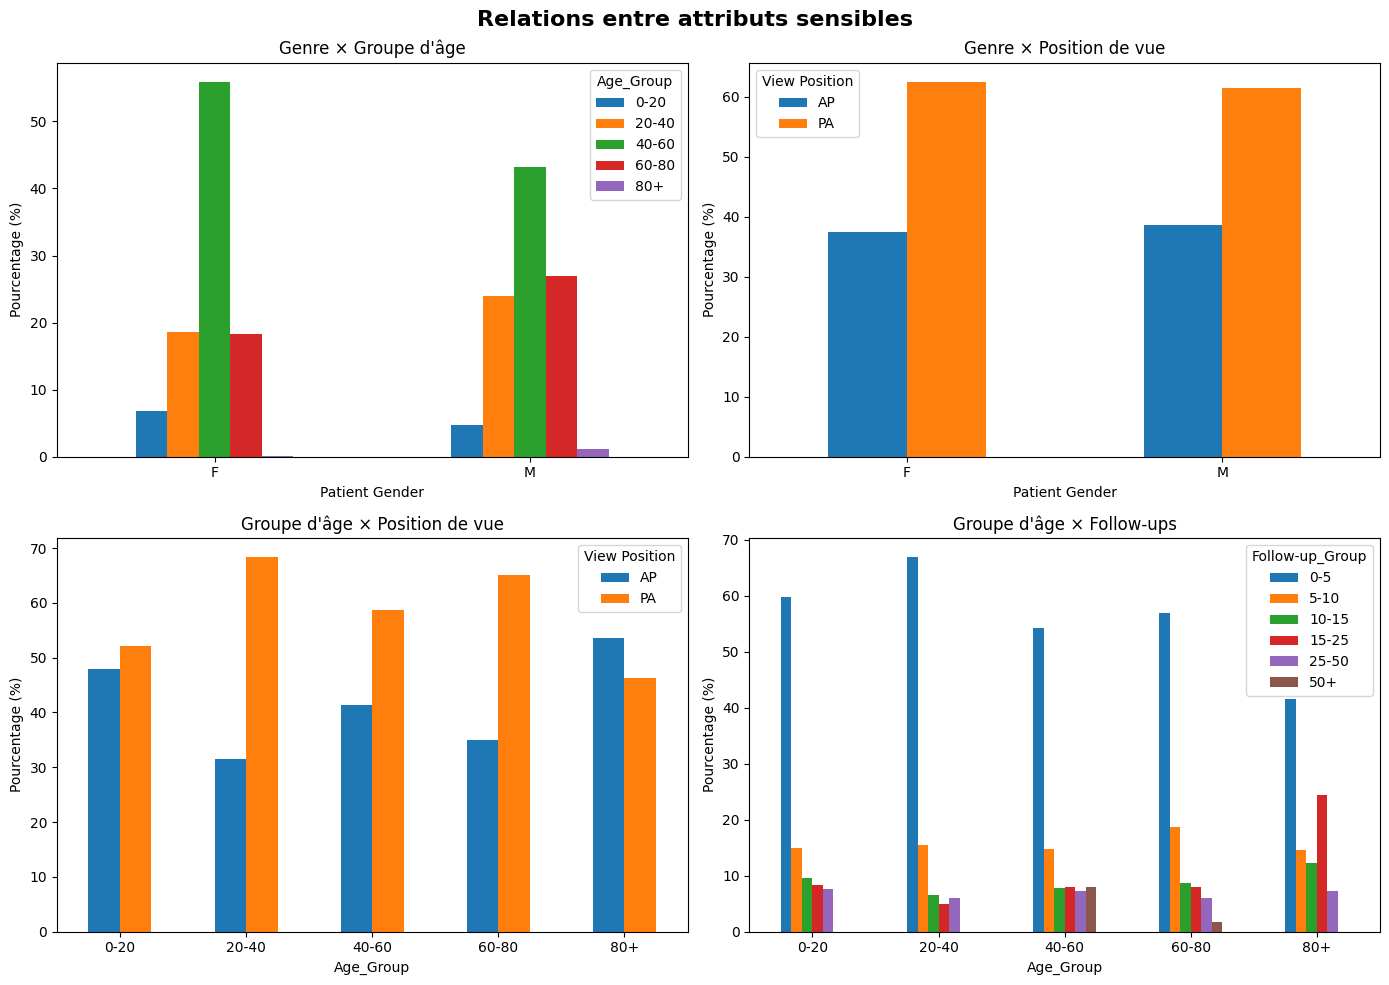

In [82]:
# Genre × Age_Group
table_genre_age = pd.crosstab(
    df["Patient Gender"],
    df["Age_Group"],
    normalize="index"
) * 100

# Genre × View Position
table_genre_view = pd.crosstab(
    df["Patient Gender"],
    df["View Position"],
    normalize="index"
) * 100

# Age_Group × View Position
table_age_view = pd.crosstab(
    df["Age_Group"],
    df["View Position"],
    normalize="index"
) * 100

# Age_Group × Follow-up_Group
table_age_follow = pd.crosstab(
    df["Age_Group"],
    df["Follow-up_Group"],
    normalize="index"
) * 100

tables = [[table_genre_age, table_genre_view],
          [table_age_view,  table_age_follow]]

titres = [["Genre × Groupe d'âge",       "Genre × Position de vue"],
          ["Groupe d'âge × Position de vue", "Groupe d'âge × Follow-ups"]]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for i in range(2):
    for j in range(2):
        tables[i][j].plot(kind="bar", ax=axes[i][j])
        axes[i][j].set_ylabel("Pourcentage (%)")
        axes[i][j].tick_params(axis='x', rotation=0)
        axes[i][j].legend(title=tables[i][j].columns.name)
        axes[i][j].set_title(titres[i][j])

fig.suptitle("Relations entre attributs sensibles", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [83]:
## Analyse statistique — relations entre attributs sensibles

# Genre × Age_Group
chi2, p_genre_age, _, _ = chi2_contingency(pd.crosstab(df["Patient Gender"], df["Age_Group"]))

print(f"  {'Groupe d\'âge':<10} {'% Hommes':>10} {'% Femmes':>10} {'Différence':>12}")
for groupe in table_genre_age.columns:
    diff = table_genre_age.loc["M", groupe] - table_genre_age.loc["F", groupe]
    print(f"  {str(groupe):<10} {table_genre_age.loc['M', groupe]:>9.1f}%"
          f" {table_genre_age.loc['F', groupe]:>9.1f}%"
          f" {diff:>+11.2f}%")
print(f"  p-value : {p_genre_age:.4f}")

# Genre × View Position
diff_genre_view = table_genre_view.loc["M", "AP"] - table_genre_view.loc["F", "AP"]
rr_genre_view   = table_genre_view.loc["M", "AP"] / table_genre_view.loc["F", "AP"]
chi2, p_genre_view, _, _ = chi2_contingency(pd.crosstab(df["Patient Gender"], df["View Position"]))

print("\n")
print(f"  % AP Hommes        : {table_genre_view.loc['M', 'AP']:.1f}%")
print(f"  % AP Femmes        : {table_genre_view.loc['F', 'AP']:.1f}%")
print(f"  Différence H-F     : {diff_genre_view:+.2f}%")
print(f"  Risk Ratio (H/F)   : {rr_genre_view:.3f}")
print(f"  p-value            : {p_genre_view:.4f}")

# Age_Group × View Position , référence 40-60
diff_age_view = table_age_view["AP"] - table_age_view.loc["40-60", "AP"]
rr_age_view   = table_age_view["AP"] / table_age_view.loc["40-60", "AP"]
chi2, p_age_view, _, _ = chi2_contingency(pd.crosstab(df["Age_Group"], df["View Position"]))

print("\n")
print(f"  {'Groupe':<10} {'% AP':>8} {'Différence':>12} {'Risk Ratio':>12}")
for groupe in table_age_view.index:
    print(f"  {str(groupe):<10} {table_age_view.loc[groupe, 'AP']:>7.1f}%"
          f" {diff_age_view[groupe]:>+11.2f}%"
          f" {rr_age_view[groupe]:>12.3f}")
print(f"  p-value : {p_age_view:.4f}")

# Age_Group × Follow-up_Group , référence 40-60
diff_age_follow = table_age_follow["0-5"] - table_age_follow.loc["40-60", "0-5"]
rr_age_follow   = table_age_follow["0-5"] / table_age_follow.loc["40-60", "0-5"]
chi2, p_age_follow, _, _ = chi2_contingency(pd.crosstab(df["Age_Group"], df["Follow-up_Group"]))

print("\n")
print(f"  {'Groupe':<10} {'% 0-5 visites':>14} {'Différence':>12} {'Risk Ratio':>12}")
for groupe in table_age_follow.index:
    print(f"  {str(groupe):<10} {table_age_follow.loc[groupe, '0-5']:>13.1f}%"
          f" {diff_age_follow[groupe]:>+11.2f}%"
          f" {rr_age_follow[groupe]:>12.3f}")
print(f"  p-value : {p_age_follow:.4f}")

  Groupe d'âge   % Hommes   % Femmes   Différence
  0-20             4.8%       6.9%       -2.11%
  20-40           24.0%      18.6%       +5.33%
  40-60           43.2%      55.9%      -12.71%
  60-80           26.9%      18.4%       +8.56%
  80+              1.1%       0.2%       +0.93%
  p-value : 0.0000


  % AP Hommes        : 38.6%
  % AP Femmes        : 37.5%
  Différence H-F     : +1.10%
  Risk Ratio (H/F)   : 1.029
  p-value            : 0.4203


  Groupe         % AP   Différence   Risk Ratio
  0-20          47.9%       +6.65%        1.161
  20-40         31.6%       -9.73%        0.764
  40-60         41.3%       +0.00%        1.000
  60-80         35.0%       -6.33%        0.847
  80+           53.7%      +12.37%        1.300
  p-value : 0.0000


  Groupe      % 0-5 visites   Différence   Risk Ratio
  0-20                59.7%       +5.45%        1.100
  20-40               67.0%      +12.73%        1.235
  40-60               54.2%       +0.00%        1.000
  60-80        

On analyse ces résultats :

Genre × Groupe d'âge : la p-value est < 0.05. Le biais est donc significatif. Les femmes sont sur-représentées dans le groupe 40-60, qui est aussi le groupe de référence le plus stable. Le modèle pourrait associer le genre féminin à un profil moins malade à cause de ce biais.

Genre × Position de vue : la p-value est > 0.05. Le biais n'est donc pas significatif. Peu importe le genre la proportion de positions de vue reste à peu près la même.

Groupe d'âge × Position de vue : la p-value est < 0.05. Le biais est donc significatif. Les très jeunes (0-20) et les très âgés (80+) sont nettement plus photographiés en AP. Le modèle pourrait donc associer la position de vue au groupe d'âge et non à la maladie.

Groupe d'âge × Follow-ups : la p-value est < 0.05. Le biais est donc significatif. Les patients jeunes ont majoritairement peu de visites alors que les 80+ en ont plus. Cependant Follow-Up n'est pas vraiment un attribut sensible comme l'âge ou le genre, c'est plutôt une conséquence de la maladie. Il est donc moins pertinent pour l'analyse de biais.

En résumé, l'analyse bivariée met en lumière deux axes de biais principaux. Le premier concerne l'âge, qui influence fortement le label (les patients âgés sont davantage malades) mais aussi la position de vue (les extrêmes d'âge sont plus souvent en AP). Le second concerne justement la position de vue AP, elle-même associée à un taux de maladie plus élevé. Le genre, en revanche, n'apparaît pas comme un facteur de biais significatif vis-à-vis du label ni de la position de vue. Le risque principal est que le modèle apprenne des raccourcis statistiques — par exemple en associant la position AP à la maladie via l'âge, plutôt qu'en détectant réellement les pathologies sur les images.

### C) Analyse trivarié

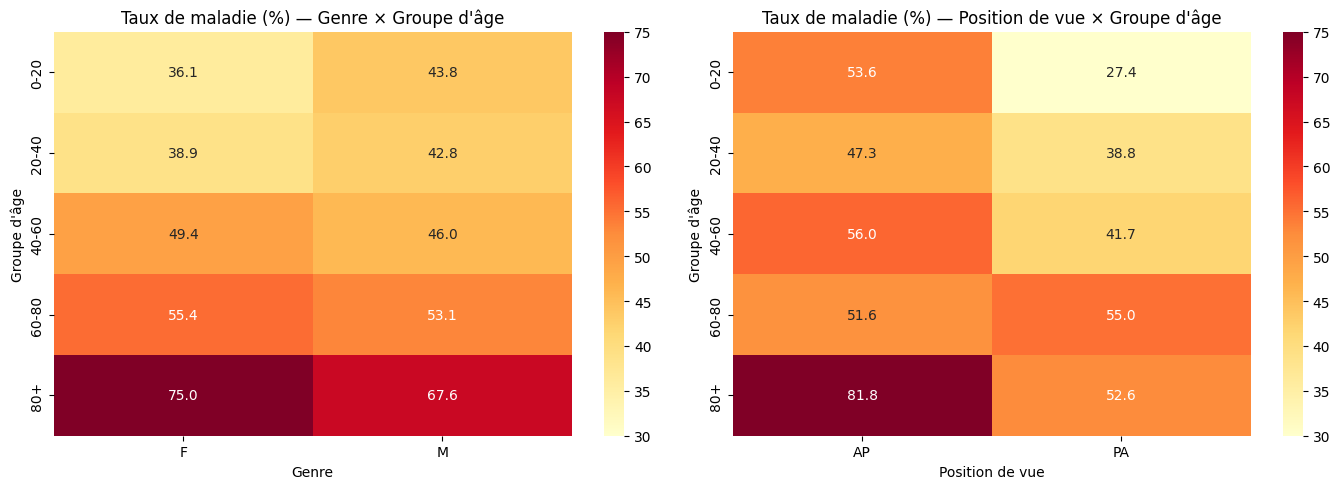

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Genre × Age_Group × label
table_genre_age_label = pd.crosstab(
    [df["Patient Gender"], df["Age_Group"]],
    df["label"],
    normalize="index"
)["malade"] * 100
heat1 = table_genre_age_label.unstack(level=0)
sns.heatmap(heat1, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[0], vmin=30, vmax=75)
axes[0].set_title("Taux de maladie (%) — Genre × Groupe d'âge")
axes[0].set_ylabel("Groupe d'âge")
axes[0].set_xlabel("Genre")

# View Position × Age_Group × label
table_view_age_label = pd.crosstab(
    [df["View Position"], df["Age_Group"]],
    df["label"],
    normalize="index"
)["malade"] * 100
heat2 = table_view_age_label.unstack(level=0)
sns.heatmap(heat2, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1], vmin=30, vmax=75)
axes[1].set_title("Taux de maladie (%) — Position de vue × Groupe d'âge")
axes[1].set_ylabel("Groupe d'âge")
axes[1].set_xlabel("Position de vue")

plt.tight_layout()
plt.show()

Genre × Groupe d'âge × label :
La tendance par âge se confirme dans les deux genres de façon uniforme. Le biais de genre reste non significatif à tous les niveaux d'âge, avec un léger écart qui s'inverse chez les 80+, mais qui est négligeable.


View Position × Groupe d'âge × label :
L'effet de l'AP est non uniforme selon l'âge. Les groupes extrêmes (0-20 et 80+) montrent des écarts AP/PA très forts, confirmant que les biais de l'âge et de la position de vue se cumulent. Le modèle risque d'apprendre ces associations plutôt que la maladie elle-même.

L'analyse trivariée confirme et affine les résultats précédents. Le genre ne modifie pas la relation entre âge et maladie : hommes et femmes suivent la même tendance d'augmentation du taux de maladie avec l'âge, ce qui conforte l'idée que le genre n'est pas un facteur de biais critique dans ce dataset. En revanche, le croisement position de vue × âge × label révèle un phénomène de cumul des biais : les groupes d'âge extrêmes (0-20 et 80+) sont à la fois plus photographiés en AP et plus souvent malades. Cette superposition crée un risque réel que le modèle confonde la position de vue avec la sévérité de la maladie.
Au terme de cette analyse exploratoire, les biais identifiés se résument ainsi : l'âge est le facteur de biais le plus structurant, influençant à la fois le label et la position de vue. La position de vue AP est un confondant potentiel important. Le genre, malgré un léger déséquilibre démographique, ne génère pas de biais significatif sur le diagnostic. Ces constats guideront la phase de pre-processing, où l'on appliquera notamment un reweighting sur les attributs sensibles pour tenter de corriger ces déséquilibres avant l'entraînement du modèle.